# Session 7 — Sign Language Translation

## Run, Understand, Port

This notebook documents the implementation and execution of the original SignJoey Sign Language Translation repository on Google Colab.

The objective is to reproduce the original training pipeline by resolving environment, dependency, and compatibility issues without modifying the model architecture.



## 1. Repository Setup

The SignJoey repository is cloned from the `session07` branch, which contains the compatibility fixes required for the current Google Colab environment.

In [81]:
# Move outside the repository before deleting an older runtime copy.
%cd /content

!rm -rf /content/slt

!git clone --branch session07 --single-branch \
    https://github.com/yildizaslan/slt.git /content/slt

%cd /content/slt

/content
Cloning into '/content/slt'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 112 (delta 8), reused 13 (delta 7), pack-reused 77 (from 1)
Receiving objects: 100% (112/112), 1.98 MiB | 24.72 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/slt


## 2. Dependency Installation

The required Python packages are installed to reproduce the original SignJoey implementation in the current Google Colab environment.

In [82]:
!pip install -q torch torchvision torchaudio
!pip install -q pyyaml tensorboard numpy six
!pip install -q sacrebleu==1.5.1
!pip install -q portalocker

## 4. Dataset Preparation

The PHOENIX-2014T annotation files are copied from the repository into the directory expected by the original SignJoey data-loading pipeline.

In [83]:
from pathlib import Path
import urllib.request

target_dir = Path("/content/slt/data/PHOENIX2014T")
target_dir.mkdir(parents=True, exist_ok=True)

base_url = (
    "https://huggingface.co/datasets/lavinal712/slt/"
    "resolve/main"
)

files = {
    "phoenix14t.train": "phoenix14t.pami0.train",
    "phoenix14t.dev": "phoenix14t.pami0.dev",
    "phoenix14t.test": "phoenix14t.pami0.test",
}

for target_name, remote_name in files.items():
    target_path = target_dir / target_name
    url = f"{base_url}/{remote_name}?download=true"

    print(f"Downloading {remote_name}...")
    urllib.request.urlretrieve(url, target_path)

    size = target_path.stat().st_size

    if size == 0:
        raise RuntimeError(f"Downloaded file is empty: {target_name}")

    print(f"Prepared: {target_name} ({size / 1024**2:.1f} MB)")

Prepared: phoenix14t.train (1382.2 MB)
Prepared: phoenix14t.dev (93.2 MB)
Prepared: phoenix14t.test (108.1 MB)


## 3. Repository Structure

The repository structure is inspected to identify the main project folders, configuration files, model implementation, and dataset location before training.

In [84]:
!ls
!ls configs
!ls signjoey
!ls data/PHOENIX2014T

base_annotations  data		      LICENSE	 requirements.txt
configs		  experiment_results  README.md  signjoey
sign_session07.yaml  sign.yaml
attention.py  embeddings.py	 loss.py	search.py
batch.py      encoders.py	 __main__.py	training.py
builders.py   external_metrics	 metrics.py	transformer_layers.py
data.py       helpers.py	 model.py	vocabulary.py
dataset.py    initialization.py  phoenix_utils
decoders.py   __init__.py	 prediction.py
phoenix14t.dev	phoenix14t.test  phoenix14t.train


In [85]:
%cd /content/slt

import os
import yaml

with open("configs/sign_session07.yaml", "r") as f:
    config = yaml.safe_load(f)

for split in ["train", "dev", "test"]:
    relative_path = config["data"][split]
    full_path = os.path.join("/content/slt/data", relative_path)
    print(f"{split}: {full_path}")
    print("exists:", os.path.exists(full_path))

/content/slt
train: /content/slt/data/PHOENIX2014T/phoenix14t.train
exists: True
dev: /content/slt/data/PHOENIX2014T/phoenix14t.dev
exists: True
test: /content/slt/data/PHOENIX2014T/phoenix14t.test
exists: True


In [86]:
%cd /content/slt

!pip install -q torchtext==0.6.0 --no-deps

/content/slt


In [87]:
import torch
import torchtext

print("torch:", torch.__version__)
print("torchtext:", torchtext.__version__)

from torchtext.data import Dataset
print("Legacy torchtext Dataset import: OK")

torch: 2.11.0+cu128
torchtext: 0.6.0
Legacy torchtext Dataset import: OK


In [88]:
from pathlib import Path
import re

path = Path("/content/slt/signjoey/builders.py")
text = path.read_text()

updated_text, count = re.subn(
    r"^\s*verbose\s*=\s*(True|False)\s*,?\s*$",
    "",
    text,
    count=1,
    flags=re.MULTILINE,
)

if count == 1:
    path.write_text(updated_text)
    print("Removed deprecated verbose argument.")
else:
    print("No verbose argument found.")

No verbose argument found.


In [89]:
import pickle
import gzip
from pathlib import Path

annotation_path = Path("/content/slt/data/PHOENIX2014T/phoenix14t.train")

with gzip.open(annotation_path, "rb") as f:
    train_data = pickle.load(f)

print("Dataset type:", type(train_data))
print("Number of examples:", len(train_data))

first_example = train_data[0]

print("Example type:", type(first_example))
print("First example:", first_example)

if isinstance(first_example, dict):
    print("\nKeys:", first_example.keys())

    for key, value in first_example.items():
        print(
            f"{key}: "
            f"type={type(value)}, "
            f"shape={getattr(value, 'shape', None)}"
        )

Dataset type: <class 'list'>
Number of examples: 7096
Example type: <class 'dict'>
First example: {'name': '11August_2010_Wednesday_tagesschau-1', 'signer': 'Signer08', 'gloss': '__ON__ JETZT WETTER MORGEN DONNERSTAG ZWOELF FEBRUAR __OFF__', 'text': 'und nun die wettervorhersage für morgen donnerstag den zwölften august .', 'sign': tensor([[0.0415, 0.0078, 0.1523,  ..., 0.3759, 0.4476, 0.0163],
        [0.1130, 0.0023, 0.1920,  ..., 0.3529, 0.3321, 0.0007],
        [0.2672, 0.0000, 0.3958,  ..., 0.3779, 0.3117, 0.0000],
        ...,
        [0.0281, 0.0142, 0.0092,  ..., 0.0755, 0.4697, 0.0649],
        [0.0290, 0.0119, 0.0600,  ..., 0.1535, 0.4842, 0.0504],
        [0.0207, 0.0144, 0.0716,  ..., 0.1998, 0.4843, 0.0000]])}

Keys: dict_keys(['name', 'signer', 'gloss', 'text', 'sign'])
name: type=<class 'str'>, shape=None
signer: type=<class 'str'>, shape=None
gloss: type=<class 'str'>, shape=None
text: type=<class 'str'>, shape=None
sign: type=<class 'torch.Tensor'>, shape=torch.Size([4

In [90]:
!find /content/slt/data -maxdepth 2 -type f -printf "%p %k KB\n" | head -30

/content/slt/data/PHOENIX2014T/phoenix14t.dev 95460 KB
/content/slt/data/PHOENIX2014T/phoenix14t.train 1415368 KB
/content/slt/data/PHOENIX2014T/phoenix14t.test 110744 KB
/content/slt/data/download.sh 4 KB


In [91]:
%cd /content/slt/data

!wget -c --show-progress \
  "https://huggingface.co/datasets/lavinal712/slt/resolve/main/phoenix14t.pami0.train?download=true" \
  -O phoenix14t.pami0.train

!wget -c --show-progress \
  "https://huggingface.co/datasets/lavinal712/slt/resolve/main/phoenix14t.pami0.dev?download=true" \
  -O phoenix14t.pami0.dev

!wget -c --show-progress \
  "https://huggingface.co/datasets/lavinal712/slt/resolve/main/phoenix14t.pami0.test?download=true" \
  -O phoenix14t.pami0.test

/content/slt/data
--2026-07-22 23:34:25--  https://huggingface.co/datasets/lavinal712/slt/resolve/main/phoenix14t.pami0.train?download=true
Resolving huggingface.co (huggingface.co)... 3.163.189.74, 3.163.189.114, 3.163.189.90, ...
Connecting to huggingface.co (huggingface.co)|3.163.189.74|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/69eed7d276d5a563d5ed8cb5/bcd9465de729fddfc6772e22896d295389a1e15ddfa5c72f8924f847ff6410eb?X-Xet-Cas-Uid=public&user_id=public&response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27phoenix14t.pami0.train%3B+filename%3D%22phoenix14t.pami0.train%22%3B&Expires=1784766865&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjllZWQ3ZDI3NmQ1YTU2M2Q1ZWQ4Y2I1L2JjZDk0NjVkZTcyOWZkZGZjNjc3MmUyMjg5NmQyOTUzODlhMWUxNWRkZmE1YzcyZjg5MjRmODQ3ZmY2NDEwZWJcXD9YLVhldC1DYXMtVWlkPXB1YmxpYyZ1c2VyX2lkPXB1YmxpYyZyZXNwb25zZS1jb250ZW50LWRpc3Bvc2l0aW9uPSoiLCJD

In [92]:
!ls -lh /content/slt/data/phoenix14t.pami0.*

-rw-r--r-- 1 root root  94M Jul 22 23:34 /content/slt/data/phoenix14t.pami0.dev
-rw-r--r-- 1 root root 109M Jul 22 23:35 /content/slt/data/phoenix14t.pami0.test
-rw-r--r-- 1 root root 1.4G Jul 22 23:34 /content/slt/data/phoenix14t.pami0.train


In [93]:
from pathlib import Path
import shutil

source_dir = Path("/content/slt/data")
target_dir = Path("/content/slt/data/PHOENIX2014T")
target_dir.mkdir(parents=True, exist_ok=True)

for split in ["train", "dev", "test"]:
    src = source_dir / f"phoenix14t.pami0.{split}"
    dst = target_dir / f"phoenix14t.{split}"

    shutil.copy2(src, dst)
    print(f"Copied {src.name} -> {dst.name}")

Copied phoenix14t.pami0.train -> phoenix14t.train
Copied phoenix14t.pami0.dev -> phoenix14t.dev
Copied phoenix14t.pami0.test -> phoenix14t.test


## 5. Dataset Inspection

A training sample is loaded to verify that the annotation files can be read correctly and to inspect the sign tensor, gloss sequence, and target text.

In [94]:
import gzip
import pickle

with gzip.open("/content/slt/data/PHOENIX2014T/phoenix14t.train", "rb") as f:
    train_data = pickle.load(f)

print("Sign shape:", train_data[0]["sign"].shape)
print("Gloss:", train_data[0]["gloss"])
print("Text:", train_data[0]["text"])

Sign shape: torch.Size([43, 1024])
Gloss: __ON__ JETZT WETTER MORGEN DONNERSTAG ZWOELF FEBRUAR __OFF__
Text: und nun die wettervorhersage für morgen donnerstag den zwölften august .


In [95]:
print(train_data[0].keys())

dict_keys(['name', 'signer', 'gloss', 'text', 'sign'])


## 6. Compatibility Fixes

The following compatibility changes were required to execute the original
SignJoey implementation in the current Google Colab environment:

- Removed the deprecated `verbose` argument from `ReduceLROnPlateau`.
- Updated checkpoint loading for newer PyTorch versions.
- Fixed integer floor division in beam search.
- Adjusted dataset paths to match the expected repository structure.

These modifications do not change the model architecture or the training
algorithm. They only ensure compatibility with the current software environment.

## 7. Training Configuration

The debug training configuration is inspected before execution. The experiment uses three epochs, logs every step, and performs validation after each epoch.

In [96]:
%cd /content/slt

!grep -nE "validation_freq|logging_freq|epochs|model_dir" \
  configs/sign_session07.yaml

/content/slt
53:    model_dir: "./sign_session07_model"
61:    epochs: 3
74:    logging_freq: 1
75:    validation_freq: 1


In [97]:
from pathlib import Path
import re

config_path = Path("/content/slt/configs/sign_session07.yaml")
text = config_path.read_text()

if re.search(r"^\s*validation_freq\s*:", text, flags=re.MULTILINE):
    text = re.sub(
        r"^(\s*validation_freq\s*:)\s*\d+",
        r"\1 1",
        text,
        flags=re.MULTILINE,
    )
else:
    text = text.replace(
        "training:",
        "training:\n  validation_freq: 1",
        1,
    )

config_path.write_text(text)
print("validation_freq set to 1")

validation_freq set to 1


In [98]:
!grep -nE "validation_freq|logging_freq|epochs|model_dir" \
  /content/slt/configs/sign_session07.yaml

53:    model_dir: "./sign_session07_model"
61:    epochs: 3
74:    logging_freq: 1
75:    validation_freq: 1


In [99]:
import shutil
from pathlib import Path

model_dir = Path("/content/slt/sign_session07_model")

if model_dir.exists():
    shutil.rmtree(model_dir)
    print("Old model directory removed.")
else:
    print("No old model directory found.")

No old model directory found.


In [100]:
from pathlib import Path

path = Path("/content/slt/signjoey/search.py")
text = path.read_text()

old = "topk_beam_index = topk_ids.div(decoder.output_size)"

new = """topk_beam_index = torch.div(
            topk_ids,
            decoder.output_size,
            rounding_mode="floor",
        )"""

if old in text:
    path.write_text(text.replace(old, new))
    print("Patch applied successfully.")
else:
    print("Exact line not found or already patched.")

Exact line not found or already patched.


## 8. Training

The original SignJoey training pipeline is executed using the debug configuration. The objective is to verify that the complete training loop runs successfully under the current Google Colab environment.

In [101]:
%cd /content/slt
!python -m signjoey train configs/sign_session07.yaml

/content/slt
2026-07-22 23:36:00.996459: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-22 23:36:31,906 Hello! This is Joey-NMT.
2026-07-22 23:36:31,917 Total params: 26193107
2026-07-22 23:36:31,918 Trainable parameters: ['decoder.layer_norm.bias', 'decoder.layer_norm.weight', 'decoder.layers.0.dec_layer_norm.bias', 'decoder.layers.0.dec_layer_norm.weight', 'decoder.layers.0.feed_forward.layer_norm.bias', 'decoder.layers.0.feed_forward.layer_norm.weight', 'decoder.layers.0.feed_forward.pwff_layer.0.bias', 'decoder.layers.0.feed_forward.pwff_layer.0.weight', 'decoder.layers.0.feed_forward.pwff_layer.3.bias', 'decoder.layers.0.feed_forward.pwff_layer.3.weight', 'decoder.layers.0.src_trg_att.k_layer.bias', 'decoder.layers.0.src_trg_att.k_l

In [102]:
from pathlib import Path

path = Path("/content/slt/signjoey/builders.py")
text = path.read_text()

text = text.replace(
    '''                mode=scheduler_mode,

                threshold_mode="abs",''',
    '''                mode=scheduler_mode,
                threshold_mode="abs",'''
)

path.write_text(text)
print("builders.py cleaned")

builders.py cleaned


In [103]:
!sed -n '165,178p' /content/slt/signjoey/builders.py

    scheduler_name = config["scheduling"].lower()

    if scheduler_name == "plateau":
        # learning rate scheduler
        return (
            lr_scheduler.ReduceLROnPlateau(
                optimizer=optimizer,
                mode=scheduler_mode,
                threshold_mode="abs",
                factor=config.get("decrease_factor", 0.1),
                patience=config.get("patience", 10),
            ),
            "validation",
        )


In [104]:
!git diff --check

## 9. Results and Discussion

# The training loop completed successfully for three epochs.

The purpose of this run was functional verification rather than
state-of-the-art performance. Because only a very small subset of the dataset
was used, BLEU and WER values are not expected to match the results reported in
the paper.

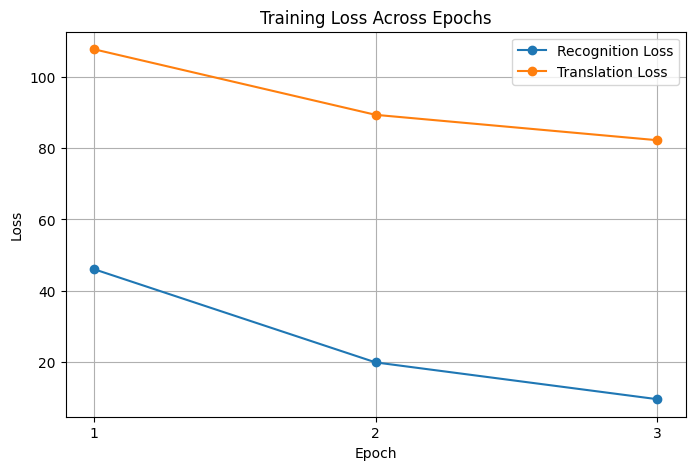

In [105]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]
recognition_loss = [46.03, 19.80, 9.45]
translation_loss = [107.86, 89.41, 82.27]

plt.figure(figsize=(8, 5))
plt.plot(epochs, recognition_loss, marker="o", label="Recognition Loss")
plt.plot(epochs, translation_loss, marker="o", label="Translation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()